In [1]:
import pandas as pd

df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [2]:
tickers = ['AAPL', 'AMZN', 'MSFT', 'GOOGL', 'NFLX', 'JPM']
df_selected = df[df['Name'].isin(tickers)]
df_selected.head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [3]:
df_selected = df_selected.sort_values(['Name', 'date'])
df_selected['daily_return'] = df_selected.groupby('Name')['close'].pct_change() * 100
df_selected.head(10)

,date,open,high,low,close,volume,Name,daily_return
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,1.042235
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-2.506658
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.190297
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.089934
1264,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL,-1.377979
1265,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL,-0.036965
1266,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL,-2.421750
1267,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL,-0.621633
1268,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,1.064925


In [4]:
volatility = df_selected.groupby('Name')['daily_return'].std().sort_values(ascending=False)
volatility

Name
NFLX     2.735256
AMZN     1.823479
AAPL     1.459301
MSFT     1.421017
GOOGL    1.387963
JPM      1.284449
Name: daily_return, dtype: float64

In [5]:
df_selected['ma_30'] = df_selected.groupby('Name')['close'].transform(lambda x: x.rolling(30).mean())
df_selected[['date', 'Name', 'close', 'ma_30']].tail(10)

,date,Name,close,ma_30
408774,2018-01-25,NFLX,269.70,207.984667
408775,2018-01-26,NFLX,274.60,210.947000
408776,2018-01-29,NFLX,284.59,214.171333
408777,2018-01-30,NFLX,278.80,217.146000
408778,2018-01-31,NFLX,270.30,219.818667
408779,2018-02-01,NFLX,265.07,222.307000
408780,2018-02-02,NFLX,267.43,224.987333
408781,2018-02-05,NFLX,254.26,227.168667
408782,2018-02-06,NFLX,265.72,229.738667
408783,2018-02-07,NFLX,264.56,232.226000


In [6]:
# Reshape data so each ticker's daily_return becomes its own column
returns_pivot = df_selected.pivot(index='date', columns='Name', values='daily_return')
returns_pivot.head()

Name,AAPL,AMZN,GOOGL,JPM,MSFT,NFLX
date,,,,,,
2013-02-08,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-11,1.042235,-1.809506,-0.375625,0.061690,1.125227,-1.701943
2013-02-12,-2.506658,0.579293,-0.219841,0.986436,0.071788,0.033841
2013-02-13,-0.190297,4.163123,0.276680,-0.936101,0.538020,4.674802
2013-02-14,-0.089934,-0.085353,0.633579,1.109285,0.035676,0.607295


In [7]:
correlation_matrix = returns_pivot.corr()
correlation_matrix

Name,AAPL,AMZN,GOOGL,JPM,MSFT,NFLX
Name,,,,,,
AAPL,1.000000,0.287659,0.348858,0.327790,0.366598,0.227387
AMZN,0.287659,1.000000,0.548423,0.291156,0.402678,0.348460
GOOGL,0.348858,0.548423,1.000000,0.356383,0.488373,0.351317
JPM,0.327790,0.291156,0.356383,1.000000,0.413488,0.243492
MSFT,0.366598,0.402678,0.488373,0.413488,1.000000,0.249646
NFLX,0.227387,0.348460,0.351317,0.243492,0.249646,1.000000


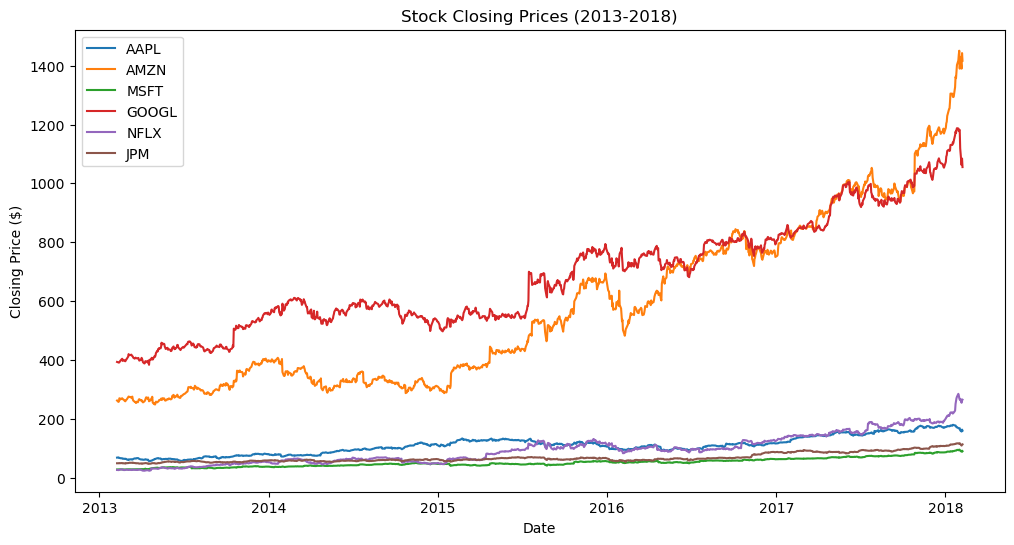

In [8]:
import matplotlib.pyplot as plt

df_selected['date'] = pd.to_datetime(df_selected['date'])

plt.figure(figsize=(12, 6))
for ticker in tickers:
    ticker_data = df_selected[df_selected['Name'] == ticker]
    plt.plot(ticker_data['date'], ticker_data['close'], label=ticker)

plt.title('Stock Closing Prices (2013-2018)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.show()

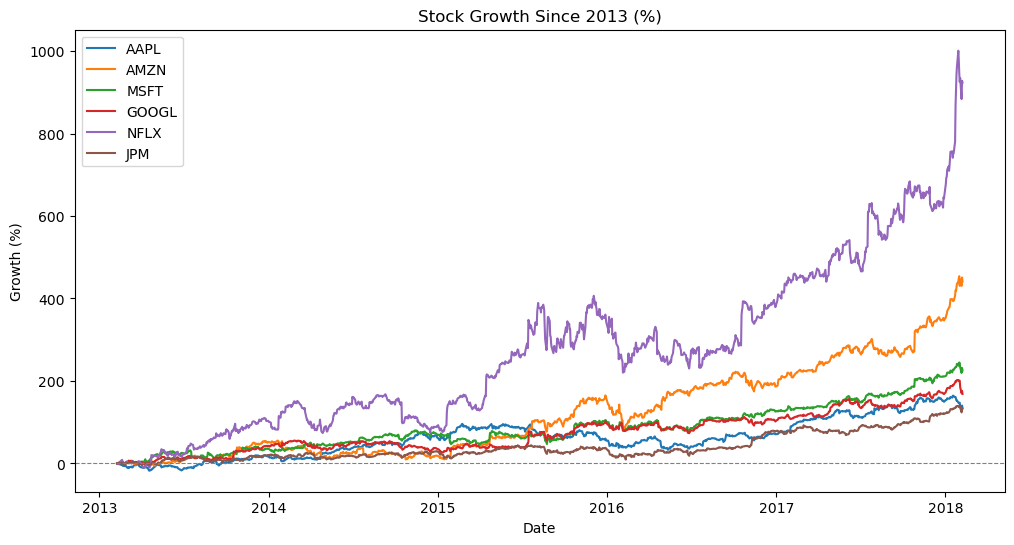

In [9]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    ticker_data = df_selected[df_selected['Name'] == ticker].copy()
    starting_price = ticker_data['close'].iloc[0]
    ticker_data['growth_pct'] = (ticker_data['close'] / starting_price - 1) * 100
    plt.plot(ticker_data['date'], ticker_data['growth_pct'], label=ticker)

plt.title('Stock Growth Since 2013 (%)')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.legend()
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

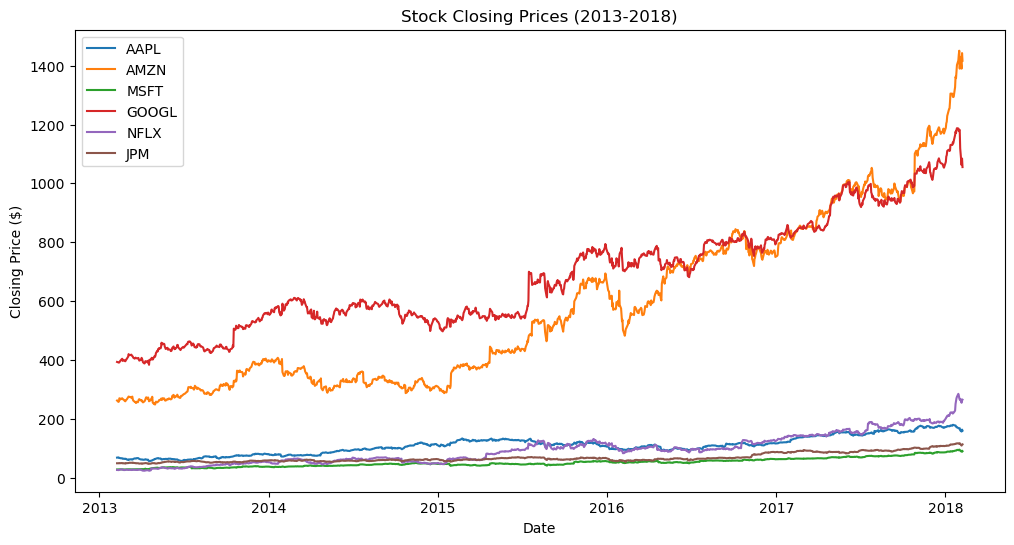

In [10]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    ticker_data = df_selected[df_selected['Name'] == ticker]
    plt.plot(ticker_data['date'], ticker_data['close'], label=ticker)
plt.title('Stock Closing Prices (2013-2018)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.savefig('chart_raw_price.png', dpi=150, bbox_inches='tight')
plt.show()

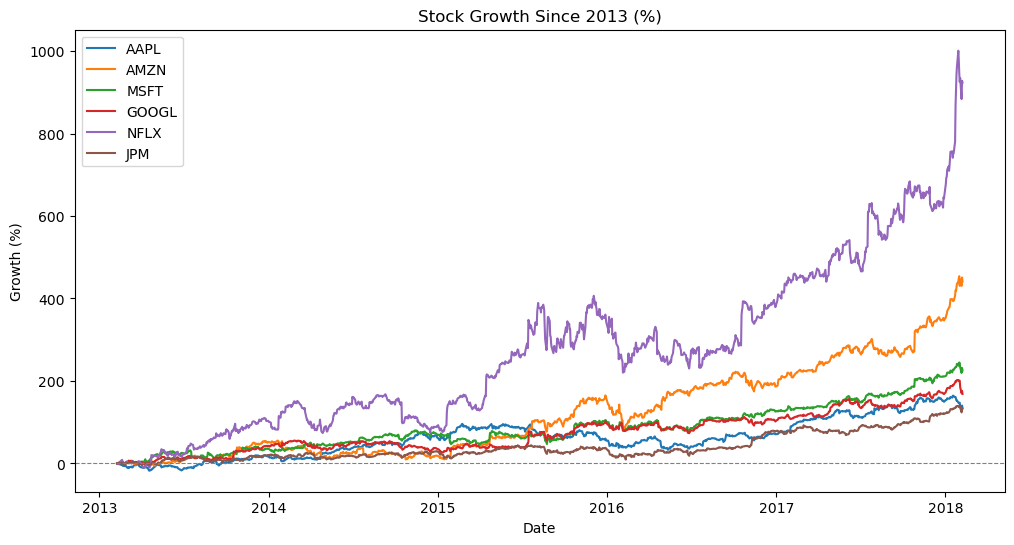

In [11]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    ticker_data = df_selected[df_selected['Name'] == ticker].copy()
    starting_price = ticker_data['close'].iloc[0]
    ticker_data['growth_pct'] = (ticker_data['close'] / starting_price - 1) * 100
    plt.plot(ticker_data['date'], ticker_data['growth_pct'], label=ticker)
plt.title('Stock Growth Since 2013 (%)')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.legend()
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.savefig('chart_growth_pct.png', dpi=150, bbox_inches='tight')
plt.show()